In [1]:
import pandas as pd
import numpy as np
import yaml
from linearmodels.panel import PanelOLS

with open('../../Settings.yaml', 'r') as file:
    Setting = yaml.safe_load(file)
#Calling Dataset
file_name = "Adjusted.xlsx"
sheet_name = 'Dataset_for_Model'
file_path = f"{Setting['Output_Path_Ajusted']}/{file_name}"
df = pd.read_excel(file_path,sheet_name = sheet_name)
  
df["Log_Labour_No"] = np.log(df["Labour_No"])
df["Log_Sale"] = np.log(df["Sale"])
df = df.set_index(["Industry_Code", "Year"]).sort_index()
X = df[["Blackout","Elec_boe_intensity","Log_Labour_No","Log_Productivity"]]
model = PanelOLS(
    df['Log_Sale'],
    X,
    entity_effects=True,  
    time_effects=True    
)
res = model.fit(cov_type='clustered', cluster_time=True,cluster_entity=True)
print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:               Log_Sale   R-squared:                        0.5863
Estimator:                   PanelOLS   R-squared (Between):              0.9159
No. Observations:                 504   R-squared (Within):               0.4211
Date:                Fri, May 01 2026   R-squared (Overall):              0.9158
Time:                        22:55:51   Log-likelihood                    109.08
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      161.59
Entities:                          24   P-value                           0.0000
Avg Obs:                       21.000   Distribution:                   F(4,456)
Min Obs:                       21.000                                           
Max Obs:                       21.000   F-statistic (robust):             59.073
                            

In [2]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

u = res.resids.dropna()        
X = X = df[["Blackout","Elec_boe_intensity","Log_Labour_No","Log_Productivity"]].loc[u.index]
X_bp = sm.add_constant(X)

lm, lm_pvalue, fval, f_pvalue = het_breuschpagan(u.values, X_bp.values)

print("Breusch–Pagan test")
print("LM stat:", lm)
print("LM p-value:", lm_pvalue)
print("F stat:", fval)
print("F p-value:", f_pvalue)

Breusch–Pagan test
LM stat: 67.9159367491941
LM p-value: 6.248674514417956e-14
F stat: 19.428623569279928
F p-value: 7.172831214693398e-15


In [3]:
# =========================
# Multicollinearity checks (Panel data)
# =========================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["Blackout","Elec_boe_intensity","Log_Labour_No","Log_Productivity"]].copy()

# ------------------------------------------------------------
# 1) VIF after "within" (demean) transformation:
#    This matches what FE uses for identification (entity + time)
#    -> most relevant for your PanelOLS with entity_effects & time_effects
# ------------------------------------------------------------

X_dm = X.copy()
entity_mean = X_dm.groupby(level=0).transform("mean")
time_mean   = X_dm.groupby(level=1).transform("mean")
overall_mean = X_dm.mean()

X_dm = X_dm - entity_mean - time_mean + overall_mean

# Drop columns that become (almost) constant after demeaning (collinear with FE)
near_zero_std = X_dm.std()
bad_cols = near_zero_std[near_zero_std < 1e-10].index.tolist()
if bad_cols:
    print("\nColumns with ~zero std after two-way demeaning (collinear with FE):")
    print(bad_cols)

# VIF on demeaned data (no constant needed; adding constant can cause issues)
X_dm2 = X_dm.drop(columns=bad_cols) if bad_cols else X_dm

vif_dm = pd.Series(
    [variance_inflation_factor(X_dm2.values, i) for i in range(X_dm2.shape[1])],
    index=X_dm2.columns,
    name="VIF_two_way_FE"
)
print("\nVIF (after two-way demeaning; most relevant for FE):")
print(vif_dm)

# ------------------------------------------------------------
# 2) Condition number / rank check (numerical collinearity)
# ------------------------------------------------------------
# Condition number (large => collinearity)
u, s, vt = np.linalg.svd(X_dm2.values, full_matrices=False)
cond_num = s.max() / s.min()
rank = np.linalg.matrix_rank(X_dm2.values)

print("\nRank:", rank, "out of", X_dm2.shape[1])
print("Condition number (two-way demeaned):", cond_num)


VIF (after two-way demeaning; most relevant for FE):
Blackout              1.096856
Elec_boe_intensity    1.047902
Log_Labour_No         1.381187
Log_Productivity      1.335825
Name: VIF_two_way_FE, dtype: float64

Rank: 4 out of 4
Condition number (two-way demeaned): 4.57255641240617


c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.draw()
c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.draw()
C:\Users\hwi\AppData\Local\Temp\ipykernel_1608\3855616230.py:58: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_1608\3855616230.py:58: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figur

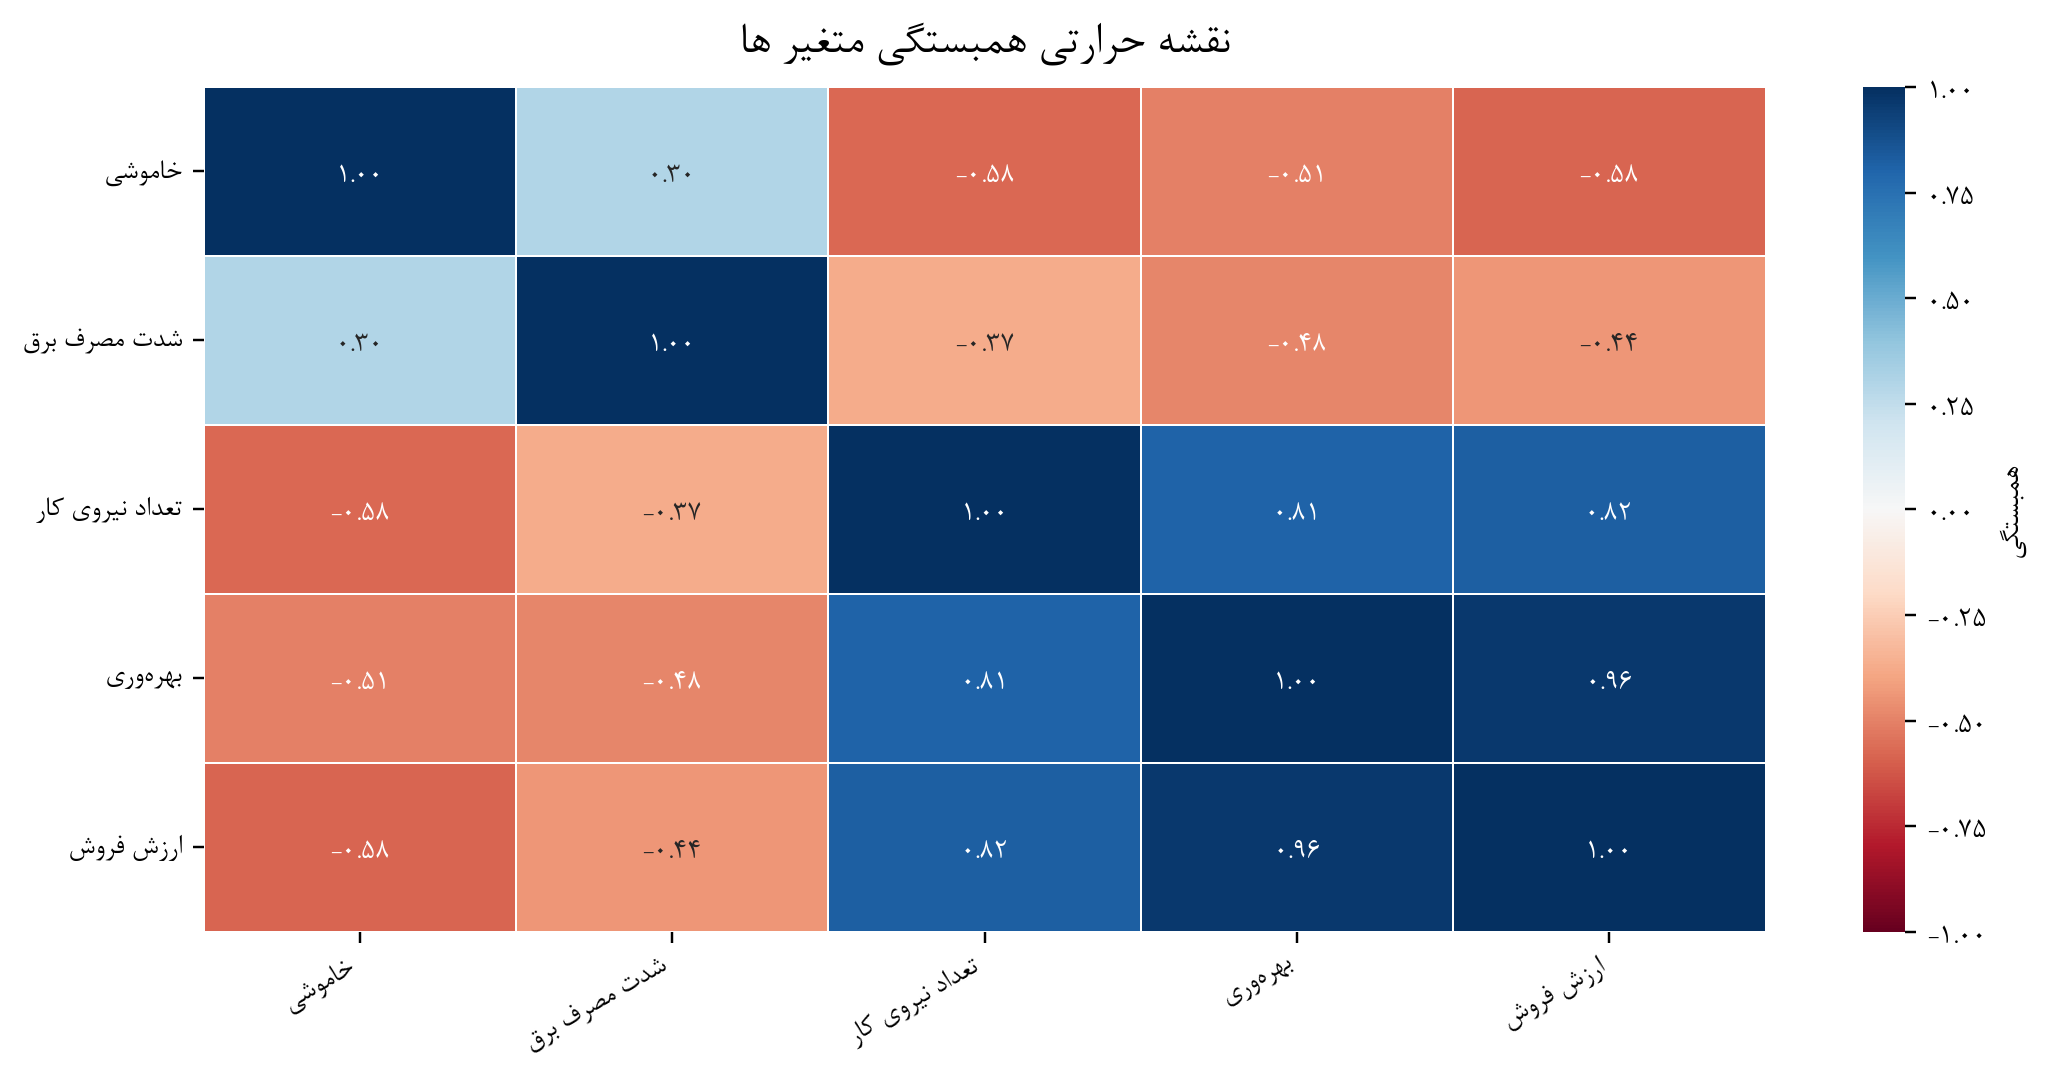

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

def fa(text):
    return get_display(arabic_reshaper.reshape(str(text)))

font_path = r"C:\USERS\HWI\APPDATA\LOCAL\MICROSOFT\WINDOWS\FONTS\B-NAZANIN.TTF"
fm.fontManager.addfont(font_path)
bnazanin = fm.FontProperties(fname=font_path)

mpl.rcParams["font.family"] = bnazanin.get_name()
mpl.rcParams["axes.unicode_minus"] = False


df["Log_Labour_No"] = np.log(df["Labour_No"])
df["Log_Sale"] = np.log(df["Sale"])

cols_needed = ["Blackout", "Elec_boe_intensity", "Log_Labour_No", "Log_Productivity", "Log_Sale"]



vars_ = ["Blackout", "Elec_boe_intensity", "Log_Labour_No", "Log_Productivity", "Log_Sale"]

labels_fa = {
    "Blackout": fa("خاموشی"),
    "Elec_boe_intensity": fa("شدت مصرف برق"),
    "Log_Labour_No": fa("تعداد نیروی کار"),
    "Log_Productivity": fa("بهره‌وری"),
    "Log_Sale": fa("ارزش فروش"),
}

corr = df[cols_needed][vars_].corr(method="pearson")
corr_fa = corr.rename(index=labels_fa, columns=labels_fa)


plt.figure(figsize=(10, 5), dpi=220)

ax = sns.heatmap(
    corr_fa,
    annot=True, fmt=".2f",
    cmap="RdBu", center=0,
    vmin=-1, vmax=1,
    linewidths=0.6, linecolor="white",
    cbar_kws={"label": fa("همبستگی")}
)

ax.set_title(fa("نقشه حرارتی همبستگی متغیر ها"), pad=12,fontsize=16)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [5]:
dfr = df.reset_index()

y_col = ["Log_Sale"]
x_cols =["Blackout","Elec_boe_intensity","Log_Labour_No","Log_Productivity"]



cols = y_col + x_cols

tmp = dfr[cols].replace([np.inf, -np.inf], np.nan)

desc = tmp.describe(percentiles=[0.25, 0.5, 0.75]).T
desc = desc.rename(columns={"25%": "q25", "50%": "median", "75%": "q75"})
pd.DataFrame(desc)

,count,mean,std,min,q25,median,q75,max
Log_Sale,504.0,32.066197,1.583215,27.647480,30.800582,31.981509,33.178420,36.431099
Blackout,504.0,0.070058,0.121641,0.000042,0.003729,0.017689,0.075523,0.759162
Elec_boe_intensity,504.0,0.280614,0.146989,0.003123,0.207528,0.275885,0.343318,0.999929
Log_Labour_No,504.0,10.548917,1.145992,7.714677,9.660459,10.298532,11.594180,12.851279
Log_Productivity,504.0,23.343043,1.242422,20.188998,22.336785,23.339064,24.116097,27.042771


C:\Users\hwi\AppData\Local\Temp\ipykernel_1608\1241107015.py:58: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_1608\1241107015.py:58: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


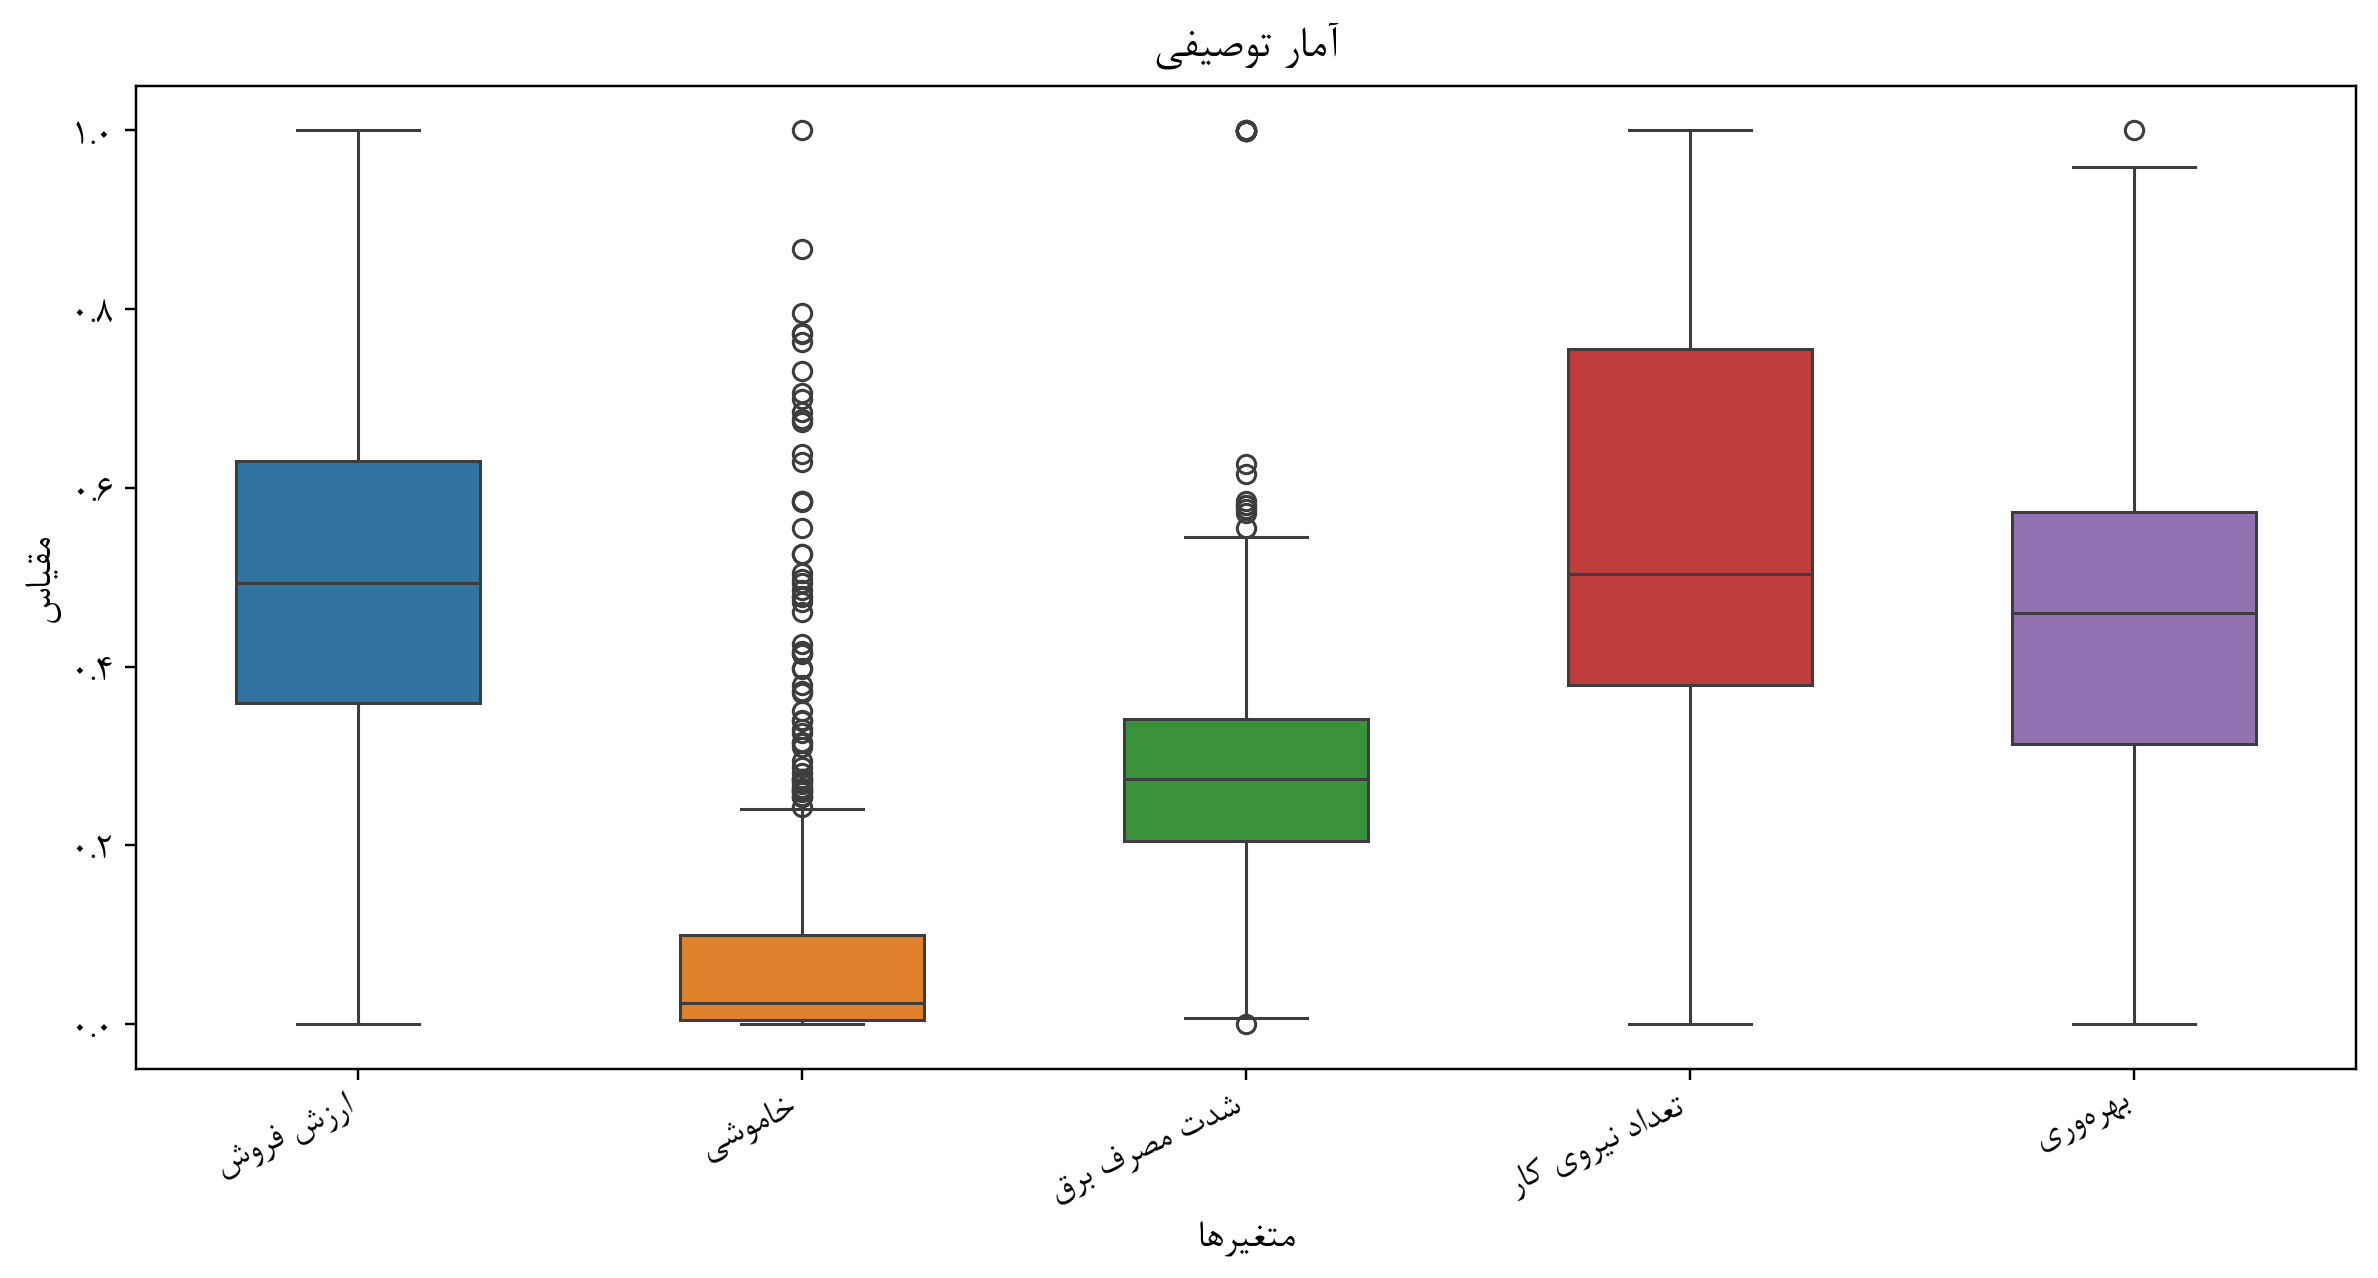

In [6]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import arabic_reshaper
from bidi.algorithm import get_display

def fa(text):
    return get_display(arabic_reshaper.reshape(str(text)))

font_path = r"C:\USERS\HWI\APPDATA\LOCAL\MICROSOFT\WINDOWS\FONTS\B-NAZANIN.TTF"
fm.fontManager.addfont(font_path)
bnazanin = fm.FontProperties(fname=font_path)

mpl.rcParams["font.family"] = bnazanin.get_name()
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["font.size"] = 13

# ---- Data
dfr = df.reset_index()
cols = ["Log_Sale", "Blackout", "Elec_boe_intensity", "Log_Labour_No", "Log_Productivity"]
tmp = dfr[cols].replace([np.inf, -np.inf], np.nan).dropna()

# ---- Min-Max scaling to [0,1]
min_ = tmp.min()
max_ = tmp.max()
den = (max_ - min_).replace(0, np.nan)
tmp_01 = (tmp - min_) / den
tmp_01 = tmp_01.fillna(0)

# Persian labels
labels_fa = {
    "Log_Sale": fa("ارزش فروش"),
    "Blackout": fa("خاموشی"),
    "Elec_boe_intensity": fa("شدت مصرف برق"),
    "Log_Labour_No": fa("تعداد نیروی کار"),
    "Log_Productivity": fa("بهره‌وری"),
}
tmp_01 = tmp_01.rename(columns=labels_fa)

# ---- Plot: orient="v" puts variables on X and values on Y
plt.figure(figsize=(11, 6), dpi=220)
ax = sns.boxplot(data=tmp_01, orient="v", width=0.55)

ax.set_title(fa("آمار توصیفی"), pad=10,fontsize = 16)
ax.set_xlabel(fa("متغیرها"),fontsize = 14)
ax.set_ylabel(fa("مقیاس"),fontsize = 14)

# Make y scale clear
ax.set_ylim(-0.05, 1.05)
ax.set_yticks(np.linspace(0, 1, 6))

# Improve readability of x labels
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_1608\1726675652.py:59: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_1608\1726675652.py:59: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


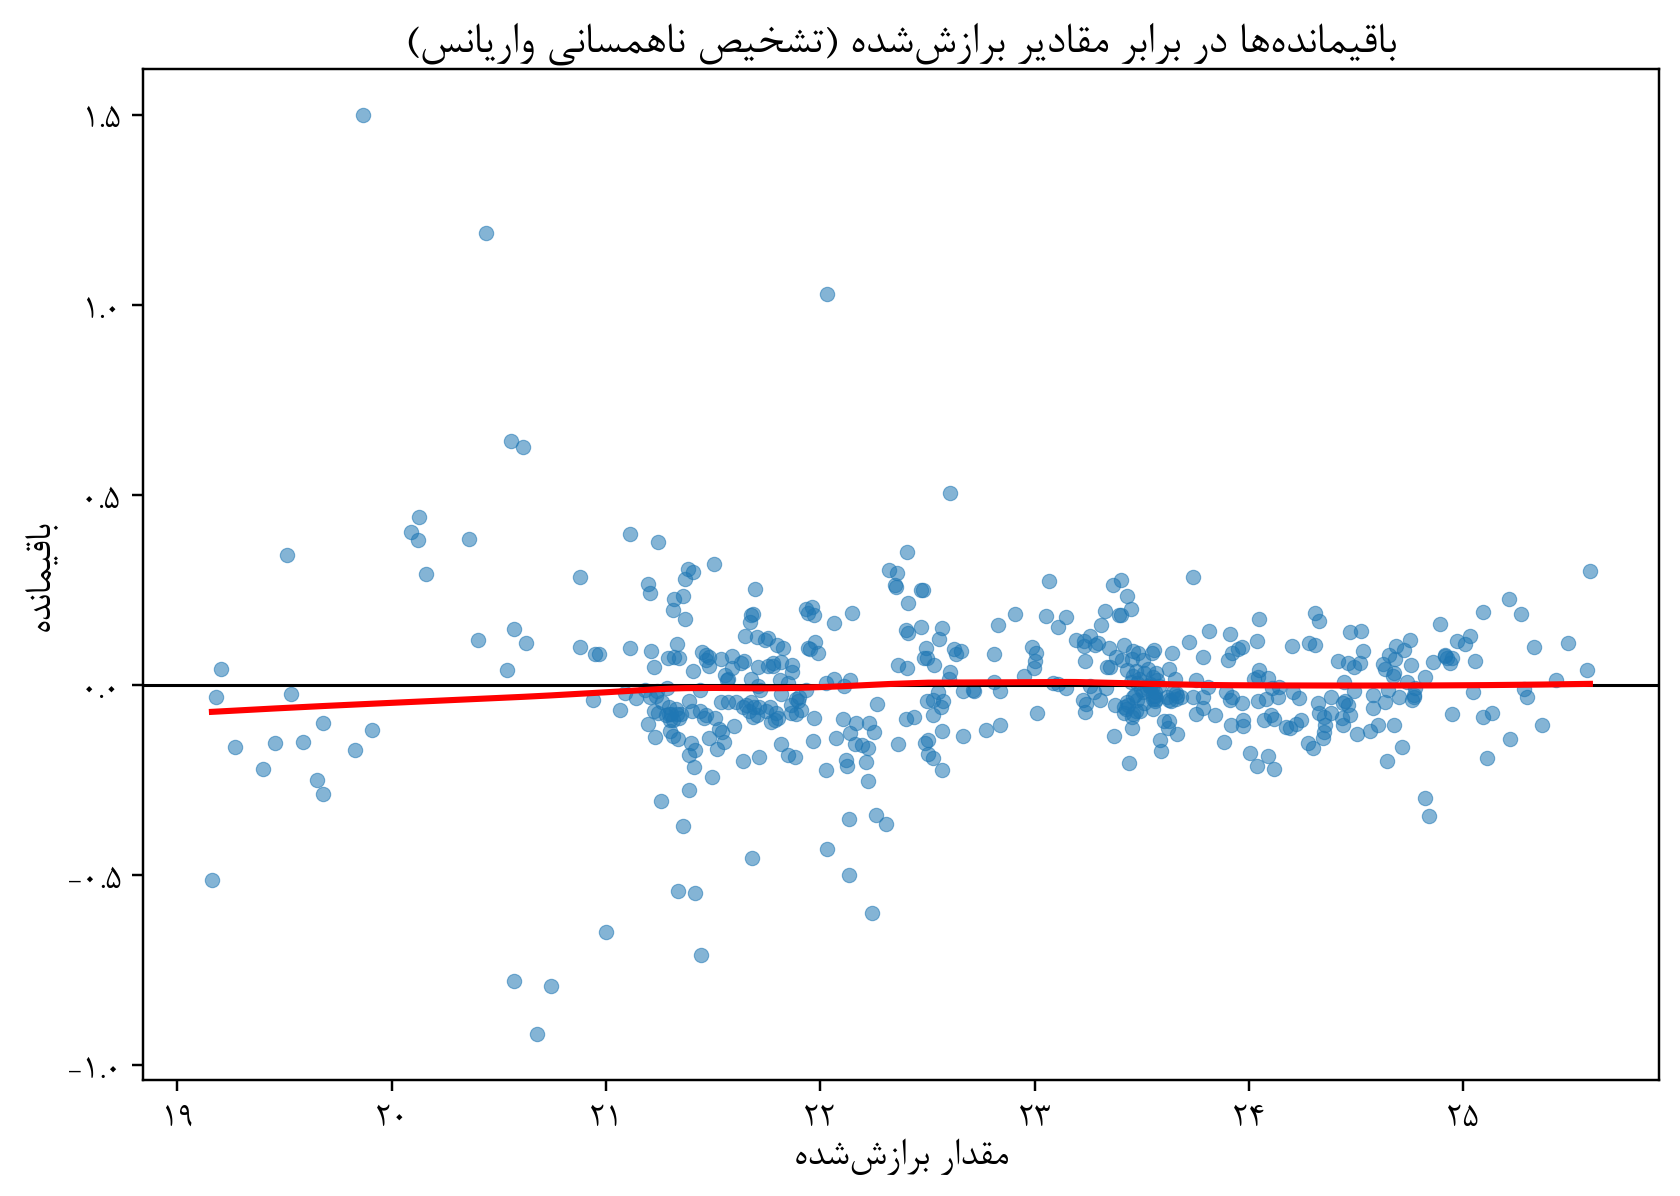

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import arabic_reshaper
from bidi.algorithm import get_display

# -------------------------
# 1) Persian helper + Font (B Nazanin)
# -------------------------
def fa(text):
    return get_display(arabic_reshaper.reshape(str(text)))

font_path = r"C:\USERS\HWI\APPDATA\LOCAL\MICROSOFT\WINDOWS\FONTS\B-NAZANIN.TTF"
fm.fontManager.addfont(font_path)
bnazanin = fm.FontProperties(fname=font_path)

mpl.rcParams["font.family"] = bnazanin.get_name()
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["font.size"] = 12

# -------------------------
# 2) Build plotting DataFrame from residuals and fitted values
# -------------------------
u = res.resids.dropna().squeeze()
yhat = res.fitted_values.dropna().squeeze()

common_idx = u.index.intersection(yhat.index)
u = u.loc[common_idx]
yhat = yhat.loc[common_idx]

plot_df = pd.DataFrame({"resid": u.values, "fitted": yhat.values}, index=common_idx)

# IMPORTANT: remove MultiIndex ambiguity by resetting index
# -> Industry_Code and Year become ONLY columns
plot_df = plot_df.reset_index()

# helper column for Scale-Location plot
plot_df["abs_resid_sqrt"] = np.sqrt(np.abs(plot_df["resid"]))

# -------------------------
# 3) Plot 1: Residuals vs Fitted (funnel check)
# -------------------------
plt.figure(figsize=(7.8, 5.6), dpi=220)
ax = sns.scatterplot(data=plot_df, x="fitted", y="resid", s=22, alpha=0.55, edgecolor=None)
ax.axhline(0, color="black", lw=1)

sns.regplot(
    data=plot_df, x="fitted", y="resid",
    scatter=False, lowess=True, color="red", line_kws={"lw": 2}
)

ax.set_title(fa("باقیمانده‌ها در برابر مقادیر برازش‌شده (تشخیص ناهمسانی واریانس)"),fontsize = 16)
ax.set_xlabel(fa("مقدار برازش‌شده"),fontsize = 14)
ax.set_ylabel(fa("باقیمانده"),fontsize = 14)
plt.tight_layout()
plt.show()